In [1]:
%pip install pandas
%pip install matplotlib
import pandas as pd
# print("Pandas version:", pd.__version__)
import glob
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Find the data files in the data folder and sort by name
data = sorted(glob.glob('data/CRMLSSOLD*.csv'))
#print(data)

In [3]:
### Read and filter the CSV files according to the task doc requirements
## Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize.

# Bedrooms ==> BedroomsTotal
# Bathrooms ==> BathroomsTotalInteger
# LotSize ==> LotSizeAcres.

# csv = pd.read_csv(data[0], usecols=['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'PropertyType', 'PropertySubType'])

## Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc).
# csv = csv[(csv['PropertyType'] == 'Residential') & (csv['PropertySubType'] == 'SingleFamilyResidence')]
# check output
# print(csv)

all_csv = []

#apply filters to all files
for file in data:
    #print(f"Processing file: {file}")
    # Explore distributions
    csv = pd.read_csv(file, usecols=['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'PropertyType', 'PropertySubType'])
    # restrict analysis per task doc
    csv = csv[(csv['PropertyType'] == 'Residential') & (csv['PropertySubType'] == 'SingleFamilyResidence')]

    all_csv.append(csv)

## Check total files read
# print(f'Total files read: {len(all_csv)}')

In [4]:
### Combine all dataframes into one
df = pd.concat(all_csv, ignore_index=True)

#Reveals amount of rows and columns of the dataframe 
print(f'Size of combined DataFrame (rows, columns): {df.shape}')

Size of combined DataFrame (rows, columns): (61727, 7)


In [5]:
### Preview the first 5 rows of the combined DataFrame
df.head()

,ClosePrice,PropertyType,LivingArea,PropertySubType,LotSizeAcres,BathroomsTotalInteger,BedroomsTotal
0,1998000.0,Residential,2045.0,SingleFamilyResidence,0.2314,2.0,4.0
1,2214421.0,Residential,3050.0,SingleFamilyResidence,0.7976,4.0,4.0
2,1200000.0,Residential,1594.0,SingleFamilyResidence,0.1515,2.0,4.0
3,3100000.0,Residential,2700.0,SingleFamilyResidence,0.1897,3.0,5.0
4,2900000.0,Residential,2948.0,SingleFamilyResidence,0.2117,4.0,5.0


In [6]:
### Summary statistics
df.describe()

,ClosePrice,LivingArea,LotSizeAcres,BathroomsTotalInteger,BedroomsTotal
count,6.172700e+04,61697.000000,60644.000000,61726.000000,61727.000000
mean,1.340106e+06,2055.552918,10.828569,2.644801,3.498437
std,7.307629e+06,1037.243701,544.530184,1.135026,0.966684
min,1.750000e+00,0.000000,0.000000,0.000000,0.000000
25%,6.200000e+05,1386.000000,0.130000,2.000000,3.000000
50%,8.900000e+05,1826.000000,0.166800,2.000000,3.000000
75%,1.425000e+06,2455.000000,0.240000,3.000000,4.000000
max,7.960000e+08,23314.000000,60113.000000,22.000000,22.000000


In [7]:
### Check for missing values
df.isnull().sum()

ClosePrice                  0
PropertyType                0
LivingArea                 30
PropertySubType             0
LotSizeAcres             1083
BathroomsTotalInteger       1
BedroomsTotal               0
dtype: int64

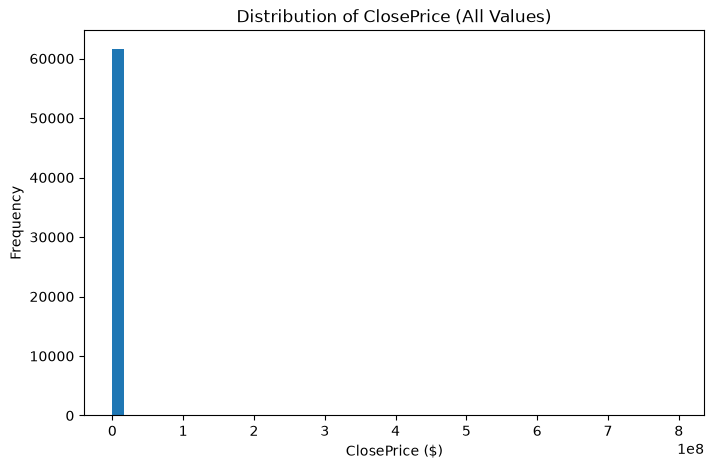

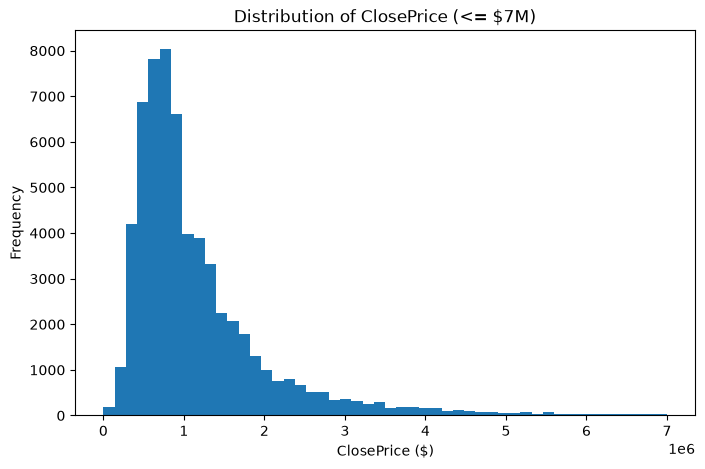

In [ ]:
### Explore Distributions
## ClosePrice
# Defn: The amount of money paid by the purchaser to the seller for the property under the agreement

# Checking for outliers and percentiles in ClosePrice values
# print(df["ClosePrice"].max()) #796,000,000
# print(df["ClosePrice"].min()) #1.75
# print(df["ClosePrice"].describe(percentiles=[0.90, 0.95, 0.99]))



# Full Distribution of ClosePrice values
plt.figure(figsize=(8, 5))
plt.hist(df["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice (All Values)")
plt.xlabel("ClosePrice ($)")
plt.ylabel("Frequency")
plt.show()

# Zoomed in on ClosePrice values less than or equal to $7M for better visualization of the distribution
plt.figure(figsize=(8, 5))
plt.hist(df[df["ClosePrice"] <= 7_000_000]["ClosePrice"], bins=50)
plt.title("Distribution of ClosePrice (<= $7M)")
plt.xlabel("ClosePrice ($)")
plt.ylabel("Frequency")
plt.show()

In [9]:
## PropertyType (= Residential)
# Defn: List of types of properties such as Residential, Lease, Income, Land, Mobile, Commercial Sale, etc.

In [10]:
##Living Area
# Defn: The total livable area within the structure.

In [11]:
## PropertySubType (= SingleFamilyResidence)
# Defn: A list of sub types to Residential, Residential Lease, Manufactured in Park, Commercial and Business Opportunity listings. e.g. Single Family Residence, Condominium, Manufactured on Land, Townhouse, Multi Family, Office, Retail, etc 


In [12]:
## LotSize = LotSizeAcres
# Defn: The total Acres of the lot.

In [13]:
## Bathrooms = BathroomsTotalInteger
# Defn: The total number of bathrooms in the property.

In [14]:
## Bedrooms = BedroomsTotal
# Defn: The total number of bedrooms in the property.
